In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [1]:
import sys
print(sys.executable)

c:\Dev\Week-5-and-6-KAIM-Fraud-Detection\venv\Scripts\python.exe


In [3]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
fraud_df.shape

(151112, 11)

In [5]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [6]:
fraud_df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [7]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [8]:
missing_values = fraud_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
fraud_df.duplicated().sum()

np.int64(0)

In [10]:
fraud_df['signup_time'] = pd.to_datetime(
    fraud_df['signup_time']
)

fraud_df['purchase_time'] = pd.to_datetime(
    fraud_df['purchase_time']
)

fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


class
0    136961
1     14151
Name: count, dtype: int64


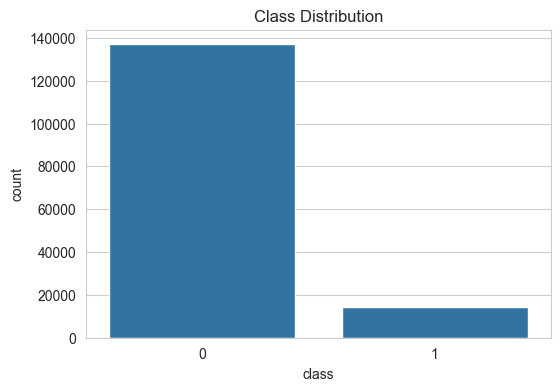

In [11]:
class_counts = fraud_df["class"].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=fraud_df, x="class")
plt.title("Class Distribution")
plt.show()

In [12]:
fraud_df["class"].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

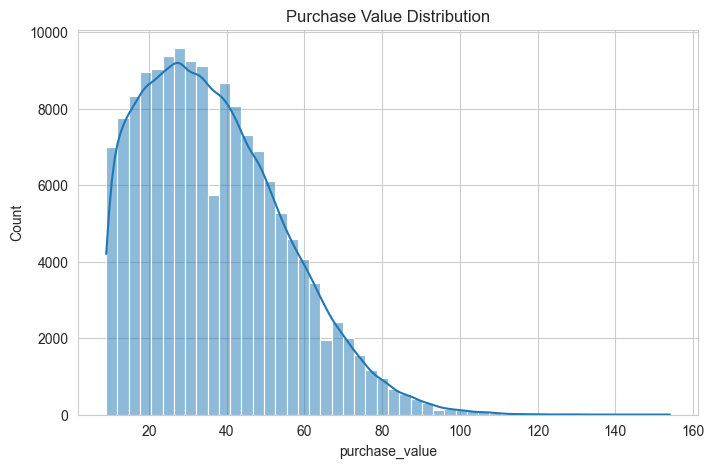

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    fraud_df["purchase_value"],
    bins=50,
    kde=True
)

plt.title("Purchase Value Distribution")
plt.show()

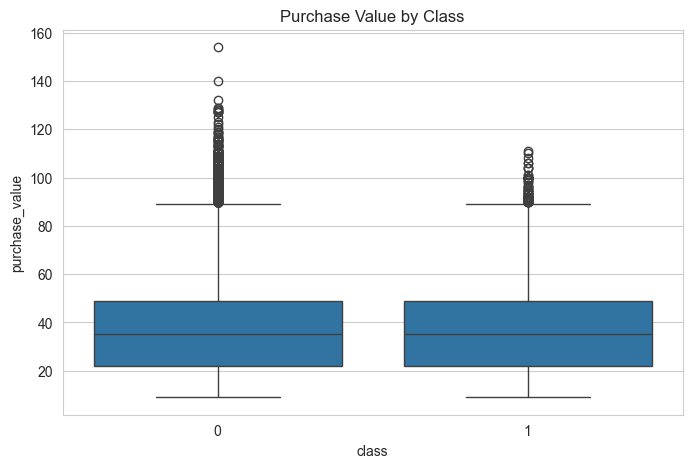

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fraud_df,
    x="class",
    y="purchase_value"
)

plt.title("Purchase Value by Class")
plt.show()

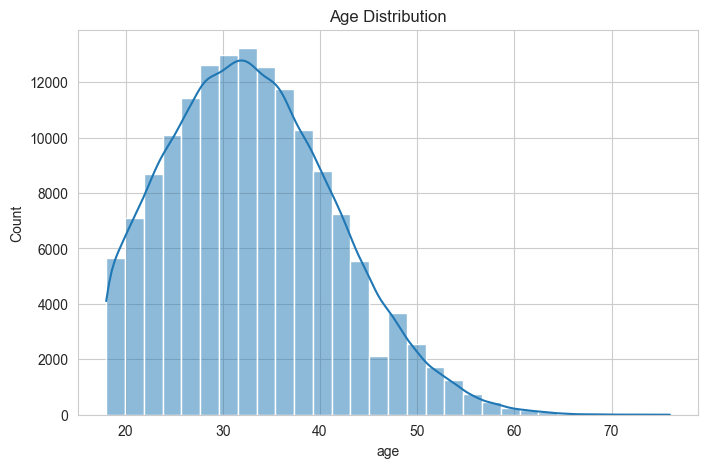

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    fraud_df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

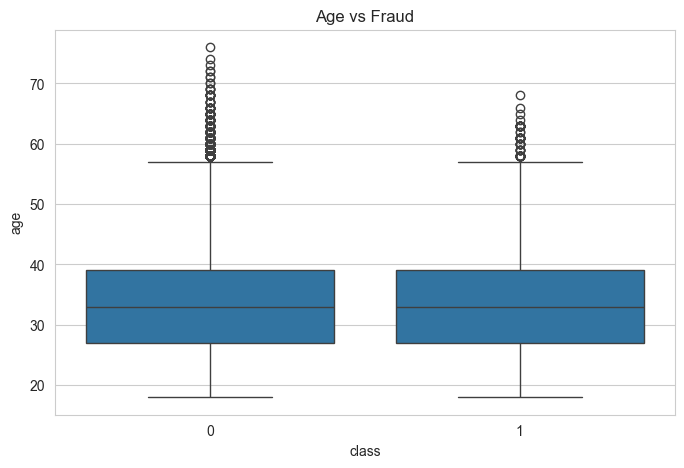

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fraud_df,
    x="class",
    y="age"
)

plt.title("Age vs Fraud")
plt.show()

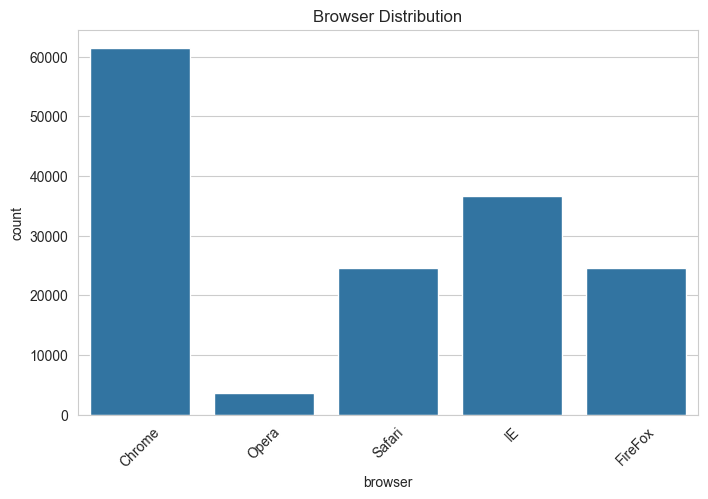

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x="browser"
)

plt.title("Browser Distribution")
plt.xticks(rotation=45)
plt.show()

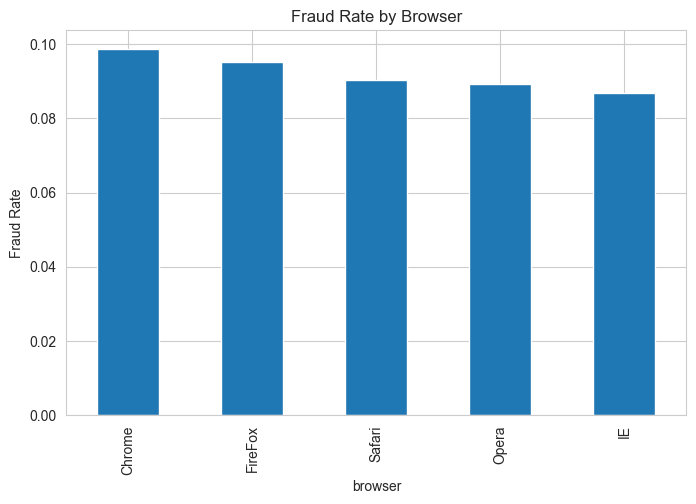

In [18]:
browser_fraud = (
    fraud_df.groupby("browser")["class"]
    .mean()
    .sort_values(ascending=False)
)

browser_fraud.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Browser")
plt.show()

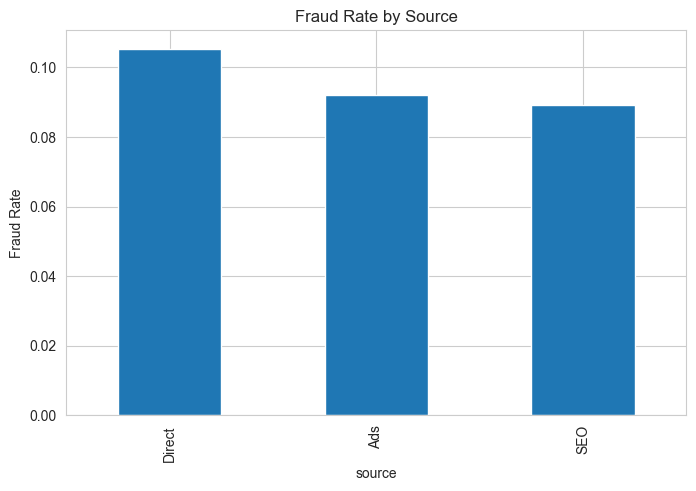

In [20]:
source_fraud = (
    fraud_df.groupby("source")["class"]
    .mean()
    .sort_values(ascending=False)
)

source_fraud.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Source")
plt.show()

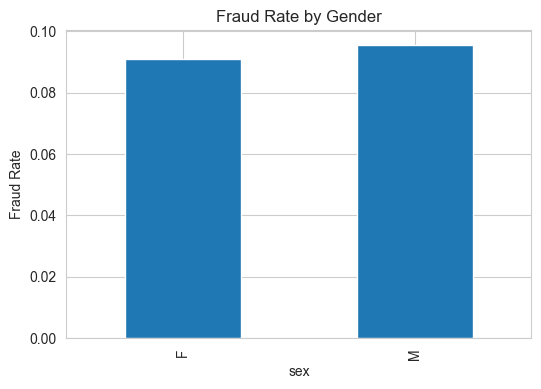

In [21]:
gender_fraud = (
    fraud_df.groupby("sex")["class"]
    .mean()
)

gender_fraud.plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Gender")
plt.show()